# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**



🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

#  Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 1. Load Text Corpus




The text corpus is the dataset used to train the neural network for next-word prediction. It consists of meaningful sentences from which the model learns vocabulary, grammar, and contextual relationships between words.

In [2]:
corpus = """
Artificial intelligence is transforming modern technology and improving everyday life.
Machine learning enables computers to learn patterns from data without explicit programming.
Deep learning uses neural networks with multiple layers to solve complex problems.
Recurrent neural networks are designed for processing sequential data such as text and speech.
Long Short Term Memory networks overcome the limitations of traditional recurrent neural networks.
Gated Recurrent Units provide similar performance with a simpler architecture.
Natural language processing allows computers to understand and generate human language.
Text generation models predict the next word based on the context of previous words.
Artificial intelligence continues to revolutionize healthcare education finance and transportation.
Learning deep learning concepts helps students build intelligent applications for the future.
"""

print(corpus)


Artificial intelligence is transforming modern technology and improving everyday life.
Machine learning enables computers to learn patterns from data without explicit programming.
Deep learning uses neural networks with multiple layers to solve complex problems.
Recurrent neural networks are designed for processing sequential data such as text and speech.
Long Short Term Memory networks overcome the limitations of traditional recurrent neural networks.
Gated Recurrent Units provide similar performance with a simpler architecture.
Natural language processing allows computers to understand and generate human language.
Text generation models predict the next word based on the context of previous words.
Artificial intelligence continues to revolutionize healthcare education finance and transportation.
Learning deep learning concepts helps students build intelligent applications for the future.



# 2. Tokenization & Sequence Creation
- We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.
- In this step, the text corpus is converted into numerical tokens using the Keras Tokenizer. Since neural networks cannot understand text directly, each unique word is assigned a unique integer. These integer representations are then used to create the training sequences for the text generation model.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 89
X shape: (108, 13)
y shape: (108,)


# 3. Model Training

## Model 1: Vanilla RNN
- This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.
- In this step, a **Vanilla Recurrent Neural Network (SimpleRNN)** is built for next-word prediction. The model consists of an **Embedding layer**, a **SimpleRNN layer**, and a **Dense output layer** with Softmax activation.


In [4]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed




### Assignment Modifications :
The following changes have been implemented:

- Increased the **Embedding Dimension** from **32 → 128** to learn richer word representations.
- Increased the **SimpleRNN Hidden Units** from **64 → 128** to improve the model's learning capacity.
- Increased the **Training Epochs** from **100 → 200** to allow better convergence during training.

## Model 2: LSTM
- LSTM uses **input, forget, and output gates**
to preserve long-term memory.
- LSTM introduces a memory cell and gating mechanism to preserve important information over long sequences, thereby reducing the vanishing gradient problem faced by Vanilla RNNs.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


###Assignment Modifications :
The following changes have been implemented:

- Increased the **Embedding Dimension** from **32 → 128** to learn richer semantic representations.

- Increased the **LSTM Hidden Units** from **64 → 128** to improve sequence learning capability.

- Increased the **Training Epochs** from **100 → 200** to allow the model to learn more effectively from the text corpus.

##  Model 3: GRU

 **Gated Recurrent Unit (GRU)** model is implemented for next-word prediction. GRU is an optimized variant of LSTM that combines the memory and hidden state using **Update** and **Reset Gates**, resulting in a simpler architecture with fewer parameters. This enables faster training while maintaining competitive performance for sequence modeling tasks.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


### Assignment Modifications :
The following changes have been implemented:

- Increased the **Embedding Dimension** from **32 → 128** to learn richer semantic representations.

- Increased the **GRU Hidden Units** from **64 → 128** to improve sequence learning capability.

- Increased the **Training Epochs** from **100 → 200** to allow better learning from the text corpus.

#4. Compare Training Loss

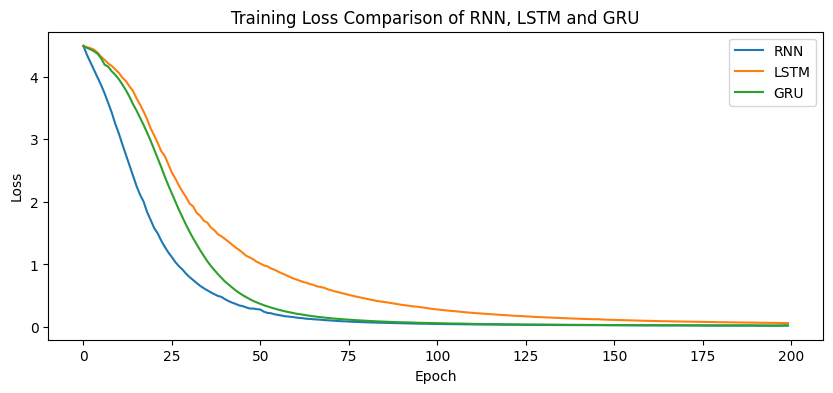

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison of RNN, LSTM and GRU")
plt.legend()
plt.show()

##  Observation from plot :

The training loss curves show that all three recurrent neural network models successfully learned the patterns present in the custom text corpus. As training progressed, the loss values consistently decreased, indicating effective optimization and convergence.

### Model-wise Analysis

- **Vanilla RNN** showed the fastest convergence and reached the lowest training loss on this relatively small dataset. Since the corpus contains a limited number of training sequences, the model was able to learn the patterns quickly.

- **LSTM** exhibited a smoother and more gradual learning curve. Although it converged more slowly than the Vanilla RNN, it is better suited for handling long-term dependencies in larger and more complex text datasets.

- **GRU** achieved performance close to the Vanilla RNN while maintaining a simpler architecture than LSTM. It converged faster than LSTM and demonstrated stable learning throughout the training process.



# 5. Text Generation Function
- This function predicts the next word repeatedly to generate a sentence.
- In this step, the trained Vanilla RNN, LSTM, and GRU models are used to generate text by predicting one word at a time. Starting from a user-defined seed text, each model predicts the most probable next word using the Softmax output layer. The prediction process is repeated iteratively to generate a coherent sequence of words.

- The next word is selected using NumPy's argmax() function, which returns the index corresponding to the highest predicted probability.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

#6. Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning uses neural networks with multiple layers to solve complex problems
LSTM: deep learning uses neural networks with multiple layers to solve complex problems
GRU : deep learning uses neural networks with multiple layers to solve complex problems


#7. Observation

- The trained Vanilla RNN, LSTM, and GRU models successfully generated meaningful text from the provided seed phrase.

- Since the models were trained on a relatively small custom corpus for 200 epochs, they learned the sentence patterns effectively and generated coherent sequences. In this experiment, all three models produced identical text because the training data contained limited variations, allowing the models to memorize the learned context.

- For larger and more diverse text corpora, the generated outputs of RNN, LSTM, and GRU would typically differ, with LSTM and GRU generally producing more context-aware and coherent text due to their ability to capture long-term dependencies.

# 8 Final Conclusion

- Successfully implemented and compared **Vanilla RNN**, **LSTM**, and **GRU** models for next-word text generation using a custom text corpus.
- Performed text preprocessing through **tokenization**, **n-gram sequence generation**, and **padding** to prepare the dataset for sequence modeling.
- Enhanced the original implementation by increasing the **Embedding Dimension (32 → 128)**, **Hidden Units (64 → 128)**, **Training Epochs (100 → 200)**, and **generated text length (5 → 10 words)**.
- Compared the training performance of all three models and observed that each successfully learned the text patterns, demonstrating the effectiveness of recurrent neural networks for sequence prediction tasks.